<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
## Custom embedddings con Gensim



### Objetivo
El objetivo es utilizar documentos / corpus para crear embeddings de palabras basado en ese contexto. Se utilizará canciones de bandas para generar los embeddings, es decir, que los vectores tendrán la forma en función de como esa banda haya utilizado las palabras en sus canciones.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import multiprocessing
try:
  from gensim.models import Word2Vec
except:
  !pip install gensim
  from gensim.models import Word2Vec

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 13.9 MB/s eta 0:00:00


### Datos
Utilizaremos como dataset canciones de bandas de habla inglesa.

In [2]:
# Descargar la carpeta de dataset
import os
import platform
if os.access('./songs_dataset', os.F_OK) is False:
    if os.access('songs_dataset.zip', os.F_OK) is False:
        if platform.system() == 'Windows':
            !curl https://raw.githubusercontent.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/main/datasets/songs_dataset.zip -o songs_dataset.zip
        else:
            !wget songs_dataset.zip https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/raw/main/datasets/songs_dataset.zip
    !unzip -q songs_dataset.zip
else:
    print("El dataset ya se encuentra descargado")

--2026-05-21 20:58:40--  http://songs_dataset.zip/
Resolving songs_dataset.zip (songs_dataset.zip)... failed: Name or service not known.
wget: unable to resolve host address ‘songs_dataset.zip’
--2026-05-21 20:58:40--  https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/raw/main/datasets/songs_dataset.zip
Resolving github.com (github.com)... 140.82.114.4
Connecting to github.com (github.com)|140.82.114.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/main/datasets/songs_dataset.zip [following]
--2026-05-21 20:58:40--  https://raw.githubusercontent.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/main/datasets/songs_dataset.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.

In [3]:
# Posibles bandas
os.listdir("./songs_dataset/")

['ludacris.txt',
 'bob-marley.txt',
 'lin-manuel-miranda.txt',
 'nicki-minaj.txt',
 'prince.txt',
 'alicia-keys.txt',
 'amy-winehouse.txt',
 'drake.txt',
 'disney.txt',
 'cake.txt',
 'johnny-cash.txt',
 'bob-dylan.txt',
 'radiohead.txt',
 'leonard-cohen.txt',
 'britney-spears.txt',
 'bieber.txt',
 'nursery_rhymes.txt',
 'paul-simon.txt',
 'bruce-springsteen.txt',
 'dj-khaled.txt',
 'lorde.txt',
 'al-green.txt',
 'dolly-parton.txt',
 'kanye.txt',
 'bruno-mars.txt',
 'rihanna.txt',
 'r-kelly.txt',
 'notorious-big.txt',
 'nirvana.txt',
 'lady-gaga.txt',
 'nickelback.txt',
 'Lil_Wayne.txt',
 'patti-smith.txt',
 'lil-wayne.txt',
 'missy-elliott.txt',
 'bjork.txt',
 'michael-jackson.txt',
 'adele.txt',
 'janisjoplin.txt',
 'beatles.txt',
 'kanye-west.txt',
 'Kanye_West.txt',
 'notorious_big.txt',
 'jimi-hendrix.txt',
 'joni-mitchell.txt',
 'eminem.txt',
 'dr-seuss.txt',
 'blink-182.txt',
 'dickinson.txt']

In [4]:
# Armar el dataset utilizando salto de línea para separar las oraciones/docs
df = pd.read_csv('songs_dataset/beatles.txt', sep='/n', header=None)
df.head()

/tmp/ipykernel_2435/3849064916.py:2: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df = pd.read_csv('songs_dataset/beatles.txt', sep='/n', header=None)


,0
0,"Yesterday, all my troubles seemed so far away"
1,Now it looks as though they're here to stay
2,"Oh, I believe in yesterday Suddenly, I'm not h..."
3,There's a shadow hanging over me.
4,"Oh, yesterday came suddenly Why she had to go ..."


In [5]:
print("Cantidad de documentos:", df.shape[0])

Cantidad de documentos: 1846


### 1 - Preprocesamiento

In [6]:
from tensorflow.keras.preprocessing.text import text_to_word_sequence

sentence_tokens = []
# Recorrer todas las filas y transformar las oraciones
# en una secuencia de palabras (esto podría realizarse con NLTK o spaCy también)
for _, row in df[:None].iterrows():
    sentence_tokens.append(text_to_word_sequence(row[0]))

In [7]:
# Demos un vistazo
sentence_tokens[:2]

[['yesterday', 'all', 'my', 'troubles', 'seemed', 'so', 'far', 'away'],
 ['now', 'it', 'looks', 'as', 'though', "they're", 'here', 'to', 'stay']]

### 2 - Crear los vectores (word2vec)

In [8]:
from gensim.models.callbacks import CallbackAny2Vec
# Durante el entrenamiento gensim por defecto no informa el "loss" en cada época
# Sobrecargamos el callback para poder tener esta información
class callback(CallbackAny2Vec):
    """
    Callback to print loss after each epoch
    """
    def __init__(self):
        self.epoch = 0

    def on_epoch_end(self, model):
        loss = model.get_latest_training_loss()
        if self.epoch == 0:
            print('Loss after epoch {}: {}'.format(self.epoch, loss))
        else:
            print('Loss after epoch {}: {}'.format(self.epoch, loss- self.loss_previous_step))
        self.epoch += 1
        self.loss_previous_step = loss

In [9]:
# Crearmos el modelo generador de vectores
# En este caso utilizaremos la estructura modelo Skipgram
w2v_model = Word2Vec(min_count=5,    # frecuencia mínima de palabra para incluirla en el vocabulario
                     window=2,       # cant de palabras antes y desp de la predicha
                     vector_size=300,       # dimensionalidad de los vectores
                     negative=20,    # cantidad de negative samples... 0 es no se usa
                     workers=1,      # si tienen más cores pueden cambiar este valor
                     sg=1)           # modelo 0:CBOW  1:skipgram

In [10]:
# Obtener el vocabulario con los tokens
w2v_model.build_vocab(sentence_tokens)

In [11]:
# Cantidad de filas/docs encontradas en el corpus
print("Cantidad de docs en el corpus:", w2v_model.corpus_count)

Cantidad de docs en el corpus: 1846


In [12]:
# Cantidad de words encontradas en el corpus
print("Cantidad de words distintas en el corpus:", len(w2v_model.wv.index_to_key))

Cantidad de words distintas en el corpus: 445


### 3 - Entrenar embeddings

In [13]:
# Entrenamos el modelo generador de vectores
# Utilizamos nuestro callback
w2v_model.train(sentence_tokens,
                 total_examples=w2v_model.corpus_count,
                 epochs=20,
                 compute_loss = True,
                 callbacks=[callback()]
                 )

Loss after epoch 0: 113045.25
Loss after epoch 1: 65966.59375
Loss after epoch 2: 65934.984375
Loss after epoch 3: 65718.390625
Loss after epoch 4: 63875.09375
Loss after epoch 5: 64160.65625
Loss after epoch 6: 64080.21875
Loss after epoch 7: 64814.875
Loss after epoch 8: 62632.75
Loss after epoch 9: 60452.875
Loss after epoch 10: 59839.875
Loss after epoch 11: 58884.375
Loss after epoch 12: 57715.75
Loss after epoch 13: 56494.3125
Loss after epoch 14: 55817.5
Loss after epoch 15: 55842.9375
Loss after epoch 16: 51722.4375
Loss after epoch 17: 49858.0
Loss after epoch 18: 49592.25
Loss after epoch 19: 48960.125


(156986, 287740)

### 4 - Ensayar

In [14]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["darling"], topn=10)

[('pretty', 0.8954247832298279),
 ('sleep', 0.8665655851364136),
 ('help', 0.8439376354217529),
 ('cry', 0.8351269960403442),
 ('not', 0.8309612274169922),
 ('try', 0.8276943564414978),
 ('peace', 0.8144856691360474),
 ('little', 0.8140572309494019),
 ('twist', 0.8123919367790222),
 ('seems', 0.8079564571380615)]

In [15]:
# Palabras que MENOS se relacionan con...:
w2v_model.wv.most_similar(negative=["love"], topn=10)

[('shake', -0.22873197495937347),
 ('four', -0.2330218255519867),
 ('five', -0.23746445775032043),
 ('six', -0.23784494400024414),
 ('bang', -0.24832050502300262),
 ('our', -0.25539135932922363),
 ('day', -0.2689811885356903),
 ('going', -0.2692062556743622),
 ('here', -0.26990723609924316),
 ('three', -0.2838989198207855)]

In [16]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["four"], topn=10)

[('five', 0.9813723564147949),
 ('three', 0.9745770692825317),
 ('six', 0.9710808992385864),
 ('seven', 0.9584357738494873),
 ('two', 0.9517216682434082),
 ('sixty', 0.8990395665168762),
 ('one', 0.7951181530952454),
 ('crying', 0.7946289777755737),
 ('us', 0.7740051746368408),
 ("i'm", 0.7508383393287659)]

In [17]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["money"], topn=5)

[("can't", 0.9434017539024353),
 ('buy', 0.9396998882293701),
 ('much', 0.9033146500587463),
 ('just', 0.8509082198143005),
 ('hide', 0.835538387298584)]

#### Ensayar con una palabra que no está en el vocabulario:
w2v_model.wv.most_similar(negative=["diedaa"])

In [19]:
# el método `get_vector` permite obtener los vectores:
vector_love = w2v_model.wv.get_vector("love")
print(vector_love)

[ 0.06138203  0.05881222 -0.06370417  0.02444947 -0.20152196 -0.18612292
 -0.15284595  0.4548753  -0.04217871  0.03536078  0.13657516 -0.18520005
 -0.1812647   0.22149836 -0.3038084  -0.23970386  0.07094695 -0.05679139
 -0.05166207 -0.23843557 -0.08530281  0.19564727 -0.07678778  0.03797247
  0.07517307 -0.04826551  0.07379535  0.10396848  0.00738022 -0.22764729
 -0.0456724   0.12937619  0.27785638  0.19387618 -0.13509148  0.20857106
  0.40917322 -0.00387122 -0.1063128  -0.09056759  0.02400028 -0.0800491
  0.13400665  0.08833536 -0.01894405  0.08592905 -0.15905626  0.10259357
  0.14459287 -0.12092585 -0.27919102 -0.04061577  0.11382084  0.31365854
 -0.07409792  0.13976744  0.22791271  0.13209458 -0.01811365  0.09772275
  0.09249583 -0.14871688 -0.16348091 -0.13203284 -0.09834065  0.02714608
  0.16531324  0.26051944 -0.0325964  -0.02894551  0.11621328 -0.06974234
  0.09563565 -0.15276384  0.22071053  0.15996666  0.1589048  -0.04711676
 -0.12555045 -0.03993924 -0.10795183  0.01878959  0.

In [21]:
# el método `most_similar` también permite comparar a partir de vectores
w2v_model.wv.most_similar(vector_love)

[('love', 0.9999999403953552),
 ('babe', 0.9085132479667664),
 ('someone', 0.8886148929595947),
 ('need', 0.8827974200248718),
 ('nothing', 0.8740269541740417),
 ("didn't", 0.8638361096382141),
 ("there's", 0.8526672720909119),
 ('you', 0.8456704616546631),
 ('feed', 0.8445017337799072),
 ('somebody', 0.8362804651260376)]

In [22]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["love"], topn=10)

[('babe', 0.9085132479667664),
 ('someone', 0.8886148929595947),
 ('need', 0.8827974200248718),
 ('nothing', 0.8740269541740417),
 ("didn't", 0.8638360500335693),
 ("there's", 0.8526672720909119),
 ('you', 0.8456703424453735),
 ('feed', 0.8445016741752625),
 ('somebody', 0.8362804651260376),
 ('buy', 0.8351694941520691)]

### 5 - Visualizar agrupación de vectores

In [23]:
from sklearn.decomposition import IncrementalPCA
from sklearn.manifold import TSNE
import numpy as np

def reduce_dimensions(model, num_dimensions = 2 ):

    vectors = np.asarray(model.wv.vectors)
    labels = np.asarray(model.wv.index_to_key)

    tsne = TSNE(n_components=num_dimensions, random_state=0)
    vectors = tsne.fit_transform(vectors)

    return vectors, labels

In [24]:
# Graficar los embedddings en 2D
import plotly.graph_objects as go
import plotly.express as px

vecs, labels = reduce_dimensions(w2v_model)

MAX_WORDS=200
fig = px.scatter(x=vecs[:MAX_WORDS,0], y=vecs[:MAX_WORDS,1], text=labels[:MAX_WORDS])
fig.show(renderer="colab") # esto para plotly en colab

In [25]:
# Graficar los embedddings en 3D

vecs, labels = reduce_dimensions(w2v_model,3)

fig = px.scatter_3d(x=vecs[:MAX_WORDS,0], y=vecs[:MAX_WORDS,1], z=vecs[:MAX_WORDS,2],text=labels[:MAX_WORDS])
fig.update_traces(marker_size = 2)
fig.show(renderer="colab") # esto para plotly en colab

#### También se pueden guardar los vectores y labels como tsv para graficar en
# http://projector.tensorflow.org/


vectors = np.asarray(w2v_model.wv.vectors)
labels = list(w2v_model.wv.index_to_key)

np.savetxt("vectors.tsv", vectors, delimiter="\t")

with open("labels.tsv", "w") as fp:
    for item in labels:
        fp.write("%s\n" % item)

# Consigna del desafío 2

**Cada experimento realizado debe estar acompañado de una explicación o interpretación de lo observado**

Recuerden que su notebook de entrega debe poder correrse de inicio a fin sin la aparición de errores.

- Crear sus propios vectores con Gensim basado en lo visto en clase con un corpus propio (revisar enlaces sugeridos en clase 2 sobre opciones de dataset)
- Elegir términos de interés y buscar términos más similares y menos similares.
- Realizar una reduccion de dimensionalidad a los embeddings, llevándolos a 2 dimensiones. Graficar los embeddings proyectados y seleccionar una cantidad de términos (variable MAX_WORDS) de forma tal que la visualización sea adecuada.
- Inspeccionar el grafico y buscar pequeños grupos de palabras que puedan formarse. Interpretarlos e intentar obtener conclusiones. En lo posible, acompañar los grupos de palabras con capturas (y pegarlas en celdas de texto)

#### Corpus: Opticks

In [26]:
# Let's load the file first.
# https://www.gutenberg.org/ebooks/33504.txt.utf-8
!wget -O optics.txt https://www.gutenberg.org/ebooks/33504.txt.utf-8

# Read
try:
    df = pd.read_csv('optics.txt', sep='/n', header=None)
    print('Opticks read as dataframe.') # Yeah, it's spelled Opticks with a k for some reason
    print("Documents (Lines):", df.shape[0])
except Exception as e:
    print('Issue reading book. Exception:')
    print(f"Error Type: {type(e).__name__}\nMessage: {e}")

# Let's convert the text into word sequences. The TF docs say the
# text_to_word_sequence method will lower the text and filter special characters.
# https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/text/text_to_word_sequence

tokens = df[0].apply(text_to_word_sequence).tolist()

--2026-05-21 20:59:49--  https://www.gutenberg.org/ebooks/33504.txt.utf-8
Resolving www.gutenberg.org (www.gutenberg.org)... 152.19.134.47, 2610:28:3090:3000:0:bad:cafe:47
Connecting to www.gutenberg.org (www.gutenberg.org)|152.19.134.47|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: http://www.gutenberg.org/cache/epub/33504/pg33504.txt [following]
--2026-05-21 20:59:54--  http://www.gutenberg.org/cache/epub/33504/pg33504.txt
Connecting to www.gutenberg.org (www.gutenberg.org)|152.19.134.47|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.gutenberg.org/cache/epub/33504/pg33504.txt [following]
--2026-05-21 20:59:54--  https://www.gutenberg.org/cache/epub/33504/pg33504.txt
Connecting to www.gutenberg.org (www.gutenberg.org)|152.19.134.47|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 596328 (582K) [text/plain]
Saving to: ‘optics.txt’

optics.txt          100%[===================>] 582.35K 

/tmp/ipykernel_2435/2699091337.py:7: ParserWarning:

Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.



In [48]:
# Model.
wtov = Word2Vec(min_count=5, window=3, vector_size=300, negative=20, workers=1, sg=1)

# Vocabulary
wtov.build_vocab(tokens)

# Docs and words.
print(f'Documents: {wtov.corpus_count}.\nWords: {len(wtov.wv.index_to_key)}')

Documents: 8783.
Words: 1732


In [49]:
wtov.train(
    tokens,
    total_examples=wtov.corpus_count,
    epochs=15,
    compute_loss = True,
    callbacks=[callback()]
) # Did a trial with more epochs, and around 15 it plateaus

Loss after epoch 0: 922830.6875
Loss after epoch 1: 720689.5625
Loss after epoch 2: 667345.5
Loss after epoch 3: 618112.5
Loss after epoch 4: 606308.75
Loss after epoch 5: 597117.0
Loss after epoch 6: 558432.0
Loss after epoch 7: 550405.5
Loss after epoch 8: 547714.5
Loss after epoch 9: 546167.5
Loss after epoch 10: 542015.5
Loss after epoch 11: 539705.0
Loss after epoch 12: 539116.0
Loss after epoch 13: 534939.0
Loss after epoch 14: 519034.0


(994952, 1569840)

#### Terms

In [50]:
word = 'red'
wtov.wv.most_similar(positive=[word], topn=10) + wtov.wv.most_similar(negative=[word], topn=10)

[('green', 0.776026725769043),
 ('pale', 0.7722169756889343),
 ('senses', 0.7658752202987671),
 ('blue', 0.7637988924980164),
 ('indigo', 0.7597898244857788),
 ('outwards', 0.7496737837791443),
 ('greenish', 0.7475500702857971),
 ('limit', 0.7443153858184814),
 ('inside', 0.7371581196784973),
 ('brighter', 0.736146867275238),
 ('propagated', -0.08244440704584122),
 ('my', -0.09172685444355011),
 ('such', -0.14154034852981567),
 ('set', -0.142238587141037),
 ('force', -0.14378508925437927),
 ('above', -0.1453198790550232),
 ('excited', -0.15048877894878387),
 ('motions', -0.152373269200325),
 ('into', -0.16958415508270264),
 ('self', -0.16986796259880066)]

We picked `red` first because, since the corpus is a treatise in optics, colour will be mentioned often. We see the most similar words being other colours, as well as other related terms, like `pale`, `senses` and `brighter`. It makes sense we see these as similar since they all revolve around the optics and are related, so one would expect they share similarities in context. The others, `outwards`, `limit` and `inside`, are interesting. It seems reasonable that `outwards` and `inside` would share contextual information, but it's hard to say why they're so similar to `red`. One explanation could be that, since optics was highly experimental back then, they show up in similar contexts which might talk a lot about experimental situations, in which light goes in and out of certain optical instruments. As for `limit`, nothing specific comes to mind as to why it would show up here.

For the least similar, we see what's expected: words that either don't hold much information by themselves, such as `my`, `such`, `into` and `self`, but also verbs like `excited` and `propagated`. We also see two interesting concepts `force` and `motions`. This makes sense from the view of 1700s optics. In 1700s classical mechanics, the nature of light wasn't understood, so terms like `force` and `motion` wouldn't exactly share contexts with other optical terms.

In [51]:
word = 'prism'
wtov.wv.most_similar(positive=[word], topn=10) + wtov.wv.most_similar(negative=[word], topn=10)

[('prisms', 0.6593466401100159),
 ('dh', 0.6537299752235413),
 ('cut', 0.6420854926109314),
 ('board', 0.6381034851074219),
 ('sideways', 0.6330136656761169),
 ('j', 0.6328845620155334),
 ('trajected', 0.6320328116416931),
 ('abc', 0.6285184621810913),
 ('parallelopiped', 0.6142224073410034),
 ('perpendicularly', 0.606410801410675),
 ('acid', -0.06291154772043228),
 ('united', -0.07756627351045609),
 ('states', -0.0864548608660698),
 ('any', -0.0992206335067749),
 ('spirit', -0.10686258971691132),
 ('such', -0.1077689528465271),
 ('other', -0.11309341341257095),
 ('or', -0.11400136351585388),
 ('you', -0.11450739949941635),
 ('electronic', -0.11528457701206207)]

We picked `prism` since it's one of the most common tools used in optics, and it was Newton who showed, via prisms, that white light could be split into every other colour. Again, we see some expected terms: `prisms`, `cut`, `board`, `sideways`, `trajected`, `parallelopiped` and `perpendicularly`. All these are reasonable, since they relate to experimental set up or other optics instruments. The others, `dh`, `j` and `abc`, I'm not sure. They could be used often when discussing optics diagrams, in which one would label points by letters, and then discuss specific rays by mentioning the points they connect, but I'm not sure.

For the least similar we again see some random words: `any`, `such`, `other`, `or` and `you`. Also there are some unrelated terms, like `acid`, `united`, `states`, `spirit` and `electronic`. This last one is interesting since, although the term was already introduced, electrical studies began properly in the 1800s, when Volta invented the battery.

In [53]:
word = 'refraction'
wtov.wv.most_similar(positive=[word], topn=10) + wtov.wv.most_similar(negative=[word], topn=10)

[('ratio', 0.6696967482566833),
 ('refractions', 0.6661690473556519),
 ('incidence', 0.6658300757408142),
 ('coast', 0.6629682183265686),
 ('obliquity', 0.6270132660865784),
 ('suffered', 0.6220164895057678),
 ('ad', 0.621049702167511),
 ('causing', 0.6145884394645691),
 ('emerging', 0.6046609282493591),
 ('sine', 0.6014969348907471),
 ('bodies', -0.06708776205778122),
 ('earth', -0.06822742521762848),
 ('all', -0.08491089195013046),
 ('electronic', -0.0897182896733284),
 ('gutenberg', -0.10024155676364899),
 ('full', -0.10030195862054825),
 ('project', -0.10096214711666107),
 ('gutenberg™', -0.10497229546308517),
 ('license', -0.10607410222291946),
 ('works', -0.10773690044879913)]

We picked `refraction` since it's one of the key phenomena in optics. Most of the terms we see are expected if you recall what the phenomena is and the concept of refraction index: `ratio`, `refractions`, `incidence`, `coast` (which means boundary), `obliquity`, `suffered`, `causing`, `emerging` and `sine`. All of these are expected, since refraction is about how the angle of transmition and incidence are different, and it's mathematical description relates the sine of these angles with the refraction indices. As for `ad`, I'm not sure.

For least similar, we see the usual, in words like `earth`, `all`, `electronic` and `full`. We also see a lot of terms relating to the Gutenberg Project itself, which might explain the aparition of electronic in the previous example. Finally we see `bodies`, which is unusual, since optics and bodies are very much related, specially optical lenses and prisms.

In [52]:
word = 'light'
wtov.wv.most_similar(positive=[word], topn=10) + wtov.wv.most_similar(negative=[word], topn=10)

[('beam', 0.6837999820709229),
 ('lights', 0.6731782555580139),
 ('st', 0.6627445816993713),
 ('direct', 0.6515072584152222),
 ('heterogeneal', 0.6514976024627686),
 ('alternately', 0.6400464177131653),
 ('co', 0.6375417113304138),
 ('whiteness', 0.6304346919059753),
 ('tv', 0.6288750767707825),
 ('mo', 0.627167820930481),
 ('set', -0.08402489870786667),
 ('glass', -0.090294249355793),
 ('with', -0.11057177931070328),
 ('you', -0.1143316924571991),
 ('sol', -0.12356137484312057),
 ('fa', -0.1296847015619278),
 ('la', -0.13221731781959534),
 ('foundation', -0.1364816576242447),
 ('well', -0.13914532959461212),
 ('up', -0.14291997253894806)]

Finally, we picked `light`, a key concept in optics. We see `beam`, `lights`, `direct`, `whiteness`, and `heterogeneal`. These are all expected, specially the first two. Heterogeneal is interesting and expected, since heterogeneous light is an old term for white light. `alternately` could also be expected here when talking about experimental work. The others, `st`, `co`, `tv` and `mo` I'm not sure.

As for least similar, we se the usuals in `set`, `with`, `you`, `foundation`, `well` and `up`. The remaining ones stand out. First, `glass`. Glass and light are highly related, especially when taking about optics, since many optical items are made out of glass, thus having a high relationship. This might be explained by the fact that glass isn't exactly a reasonably substitute to light. Finally, `sol`, `fa`, `la`. These seem to be musical notes, which were believed by many to be related to optics in that it was thought that the 7 colours of the rainbow and the 7 musical notes shared some type of mathematical harmony. Their appearance here might be explained by the fact that `light` might appear throughout the whole corpus, but these musical notes appear only in a specific section of it, but I'm not sure.

#### Dim Reduction

In [54]:
optics_v, optics_l = reduce_dimensions(wtov)

In [55]:
def show_terms(vec, lab, max_w = 200):
    fig = px.scatter(x=vec[:max_w,0], y=vec[:max_w,1], text=lab[:max_w])
    fig.show(renderer="colab")

In [62]:
show_terms(optics_v, optics_l, max_w=500)

#### Full plot

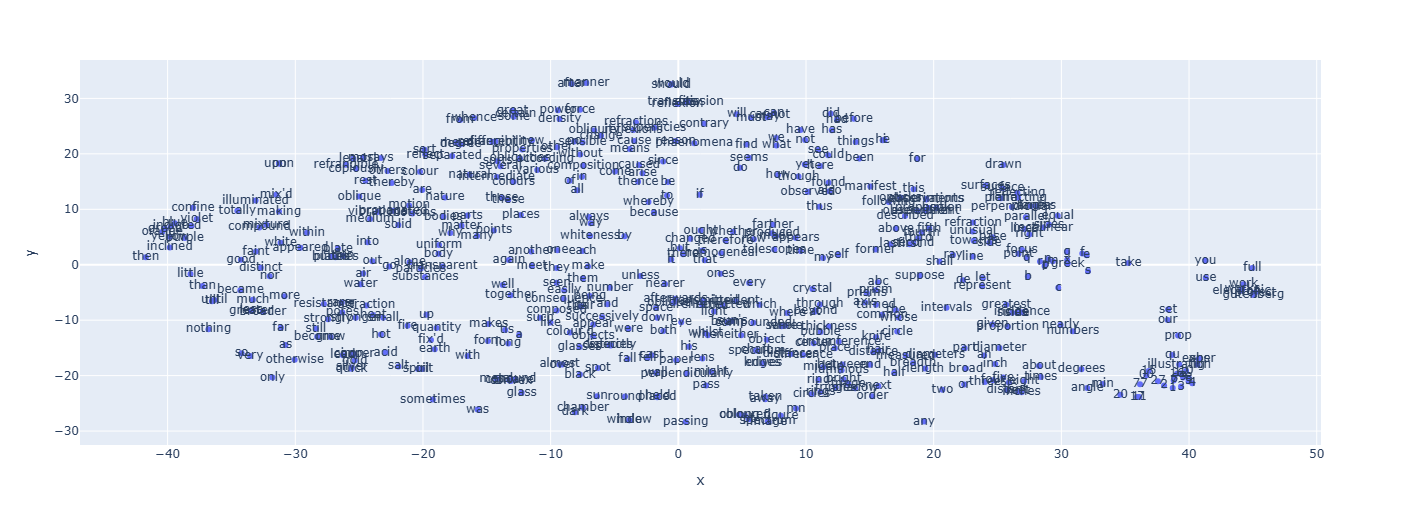

1st cluster selected: (x≈25 and y≈10)

In this plot we see refraction and reflection related terms. These are all reasonable, since they all refer to experimental arraingements. We see that surface and surfaces are very close, while plane and planes are not as close. The only one that truly stands out here is `unusual`.

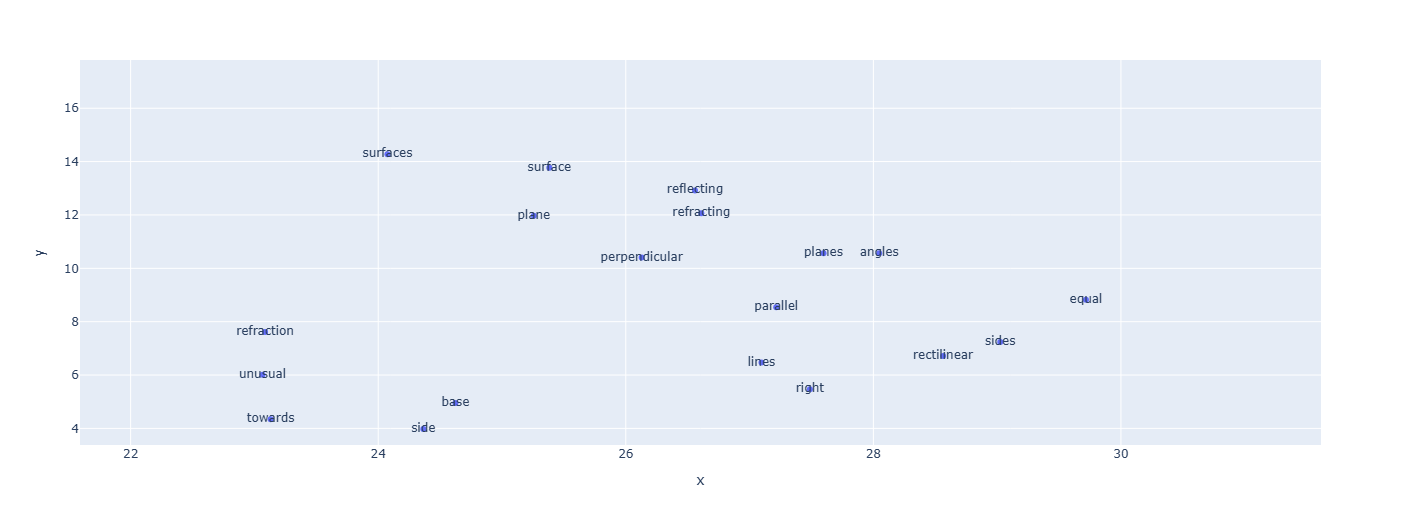

2nd cluster selected: (x≈17 and y≈12)

We picked it due to the remarkable overlap between `experiments` and `observations`, which are used interchangably in science. Experiment and observation are also very close. Expect maybe `following` and `this`, all others are expected to be close to these two, since, again, books made a big emphasis on experiments in Newton's time.

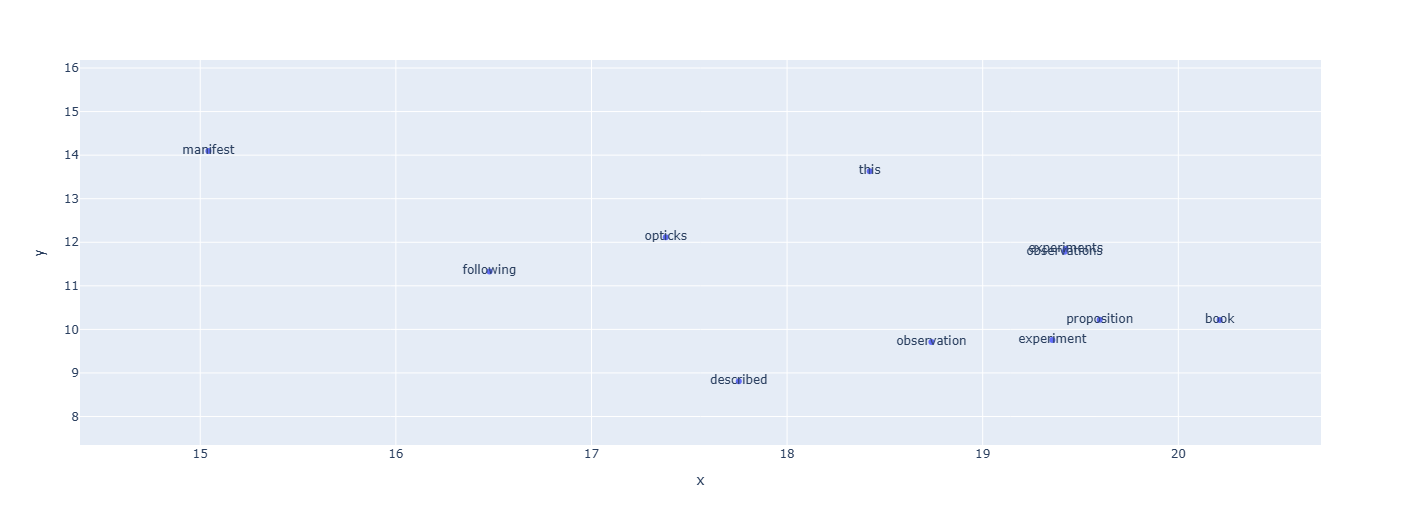

3rd cluster: (x≈38 and y≈-20)

We picked this one because it was curious. First, we see that most of these terms are just numbers, which is understandable. But also, wee see the word `illustration` here. Since in most texts diagrams and pictures are numbered, it shouldn't be surprising that these are in similar regions.

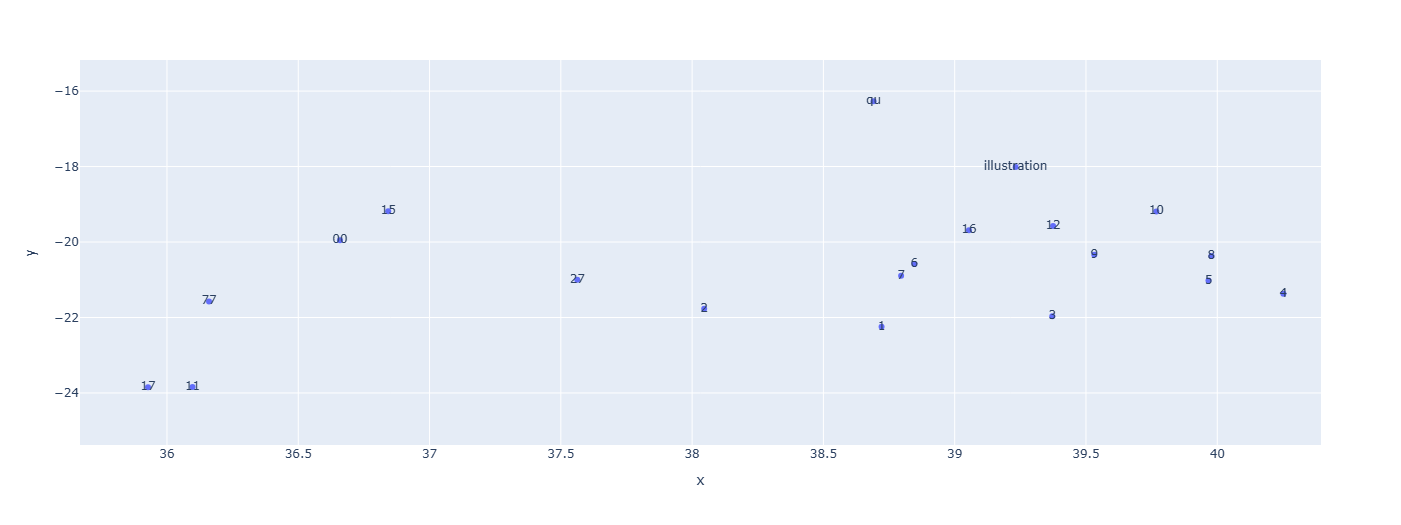

4th cluster: (x≈-40 and y≈6)

We picked this one since it contained one of the words we analyzed previously: `red`. Interestingly and expectedly, we see other colours, but we don't see words that were highly similar in the previous analysis, like `senses` or `pale`. I'm not entirely sure why this happens, it probably relates to the max words used, but I can't be 100% sure.

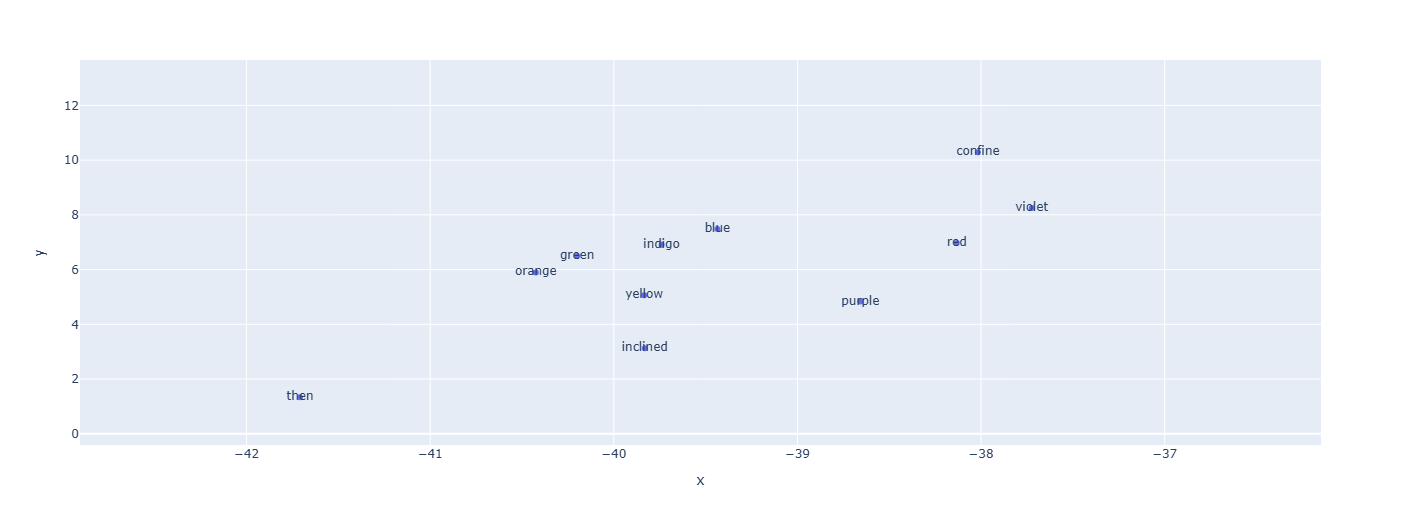

5th cluster: (x≈-25 and y≈-17)

This one we thought interesting because it's a very small cluster of metals. But the interesting bit is `quick` being here. In old english, mercury used to be called `quicksilver`, which might be the reason it appears here, but as far as I know, `quicksilver` has no space between quick and silver, so if quicksilver was mentioned in the corpus it should be its own word, rather than two separate ones.

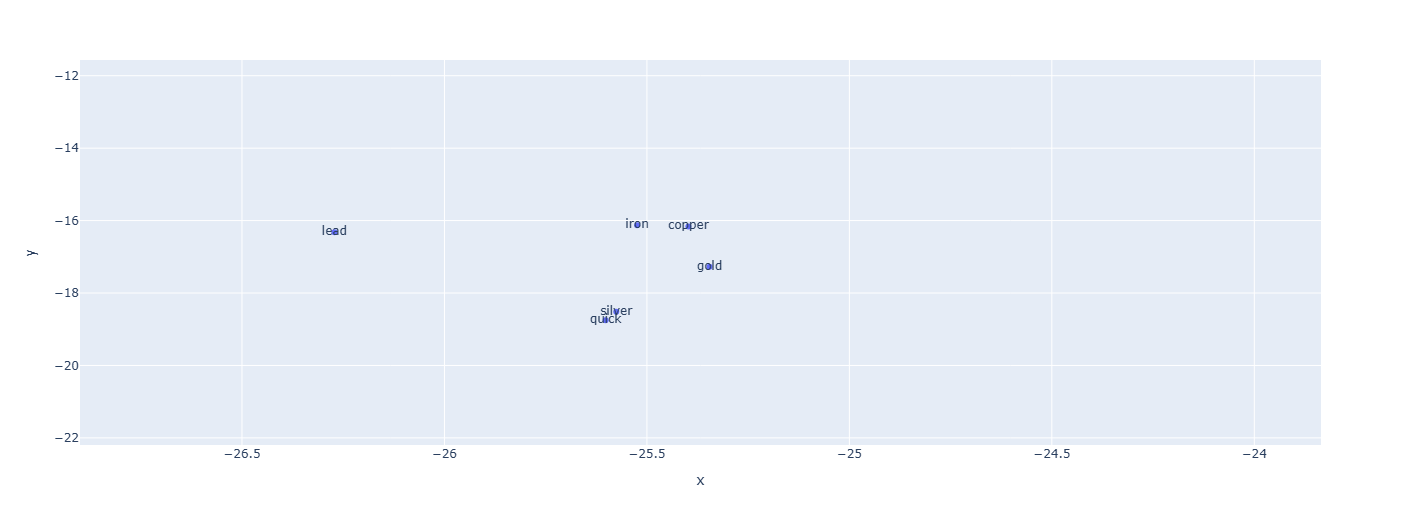